In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('supershops.csv')
df

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94
5,131876.90,99814.71,362861.36,Dhaka,156991.12
6,134615.46,147198.87,127716.82,Ctg,156122.51
7,130298.13,145530.06,323876.68,Rangpur,155752.60
8,120542.52,148718.95,311613.29,Dhaka,152211.77
9,123334.88,108679.17,304981.62,Ctg,149759.96


In [3]:
df.shape

(50, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Marketing Spend  50 non-null     float64
 1   Administration   50 non-null     float64
 2   Transport        49 non-null     float64
 3   Area             50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.isna().sum()

Marketing Spend    0
Administration     0
Transport          1
Area               0
Profit             0
dtype: int64

In [6]:
df.Area.value_counts()

Area
Dhaka      17
Ctg        17
Rangpur    16
Name: count, dtype: int64

# Visualization

In [7]:
df.head(2)

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06


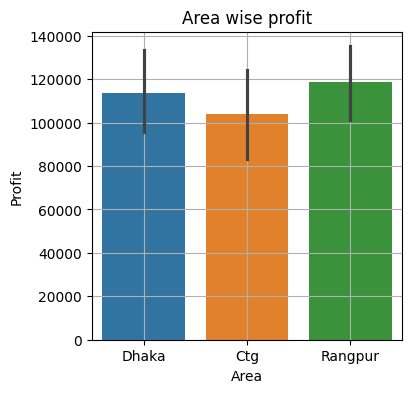

In [8]:
plt.figure(figsize = (4,4))
sns.barplot(x = df['Area'], y = df['Profit'], hue = df.Area)
plt.xlabel('Area')
plt.ylabel('Profit')
plt.title('Area wise profit')
plt.grid()
plt.show()

C:\Users\Qbits\AppData\Local\Temp\ipykernel_15280\3548980562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(area_profit, palette = 'Set1')


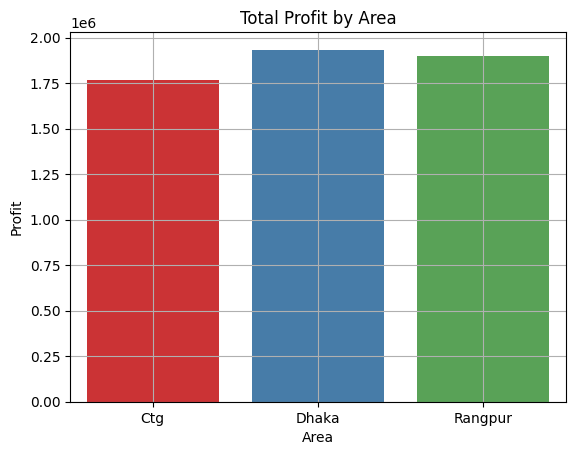

In [9]:
area_profit = df.groupby('Area')['Profit'].sum()
sns.barplot(area_profit, palette = 'Set1')
#area_profit.plot(kind='bar')
plt.title("Total Profit by Area")
plt.ylabel("Profit")
plt.grid()
plt.show()

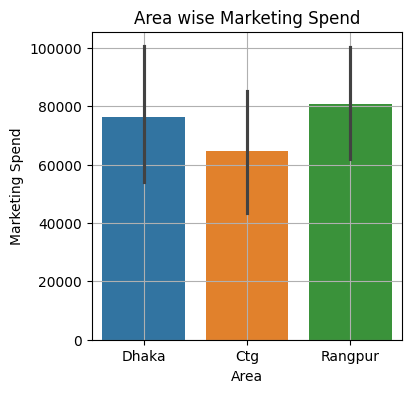

In [10]:
plt.figure(figsize = (4,4))
sns.barplot(x = df['Area'], y = df['Marketing Spend'], hue = df.Area)
plt.xlabel('Area')
plt.ylabel('Marketing Spend')
plt.title('Area wise Marketing Spend')
plt.grid()
plt.show()

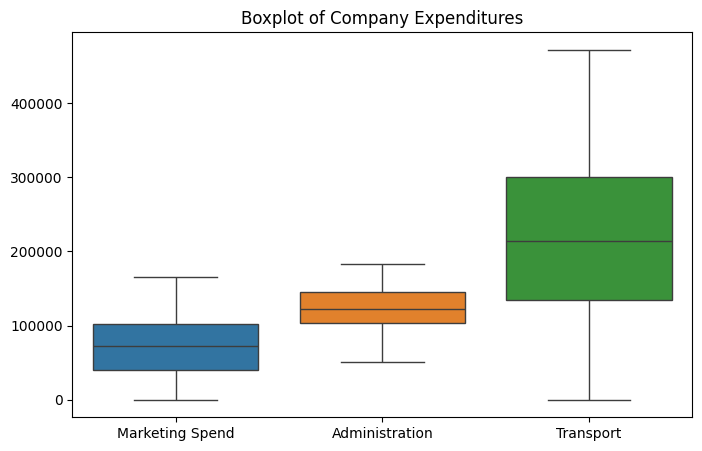

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Marketing Spend','Administration','Transport']])
plt.title("Boxplot of Company Expenditures")
plt.show()

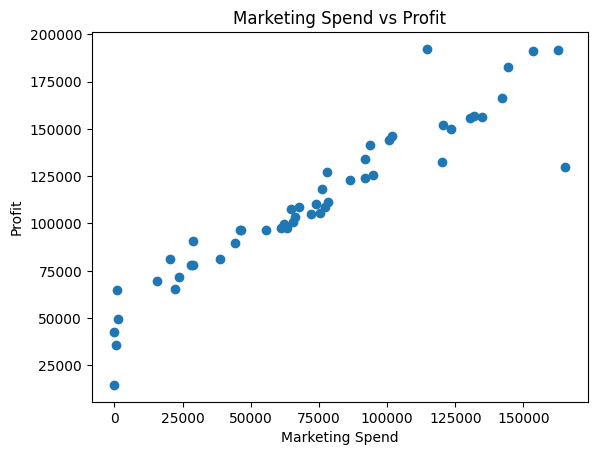

In [12]:
plt.scatter(df['Marketing Spend'], df['Profit'])
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.title("Marketing Spend vs Profit")
plt.show()

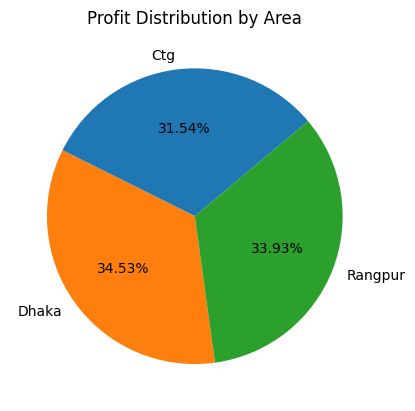

In [13]:
area_profit = df.groupby('Area')['Profit'].sum()
plt.pie(area_profit,
        labels = area_profit.index,
        autopct = '%.2f%%',
        startangle = 40)

plt.title("Profit Distribution by Area")
plt.show()

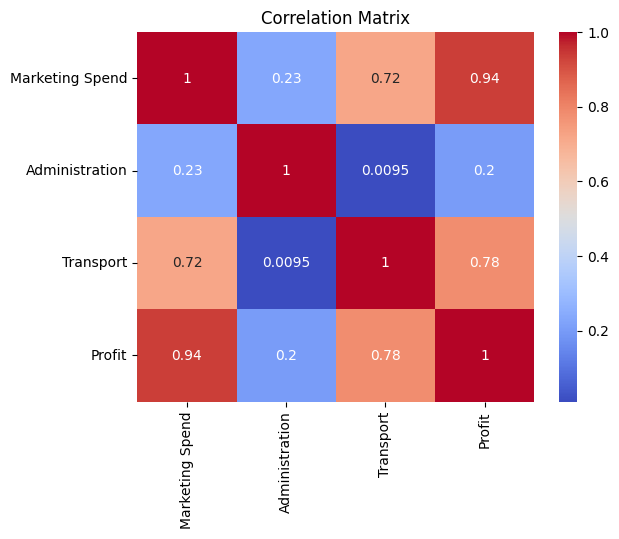

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

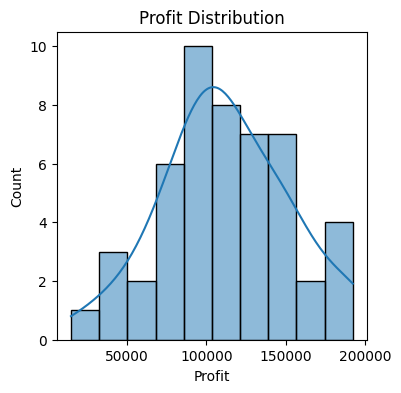

In [15]:
plt.figure(figsize = (4,4))
sns.histplot(df['Profit'], bins=10, kde=True)
plt.title("Profit Distribution")
plt.show()

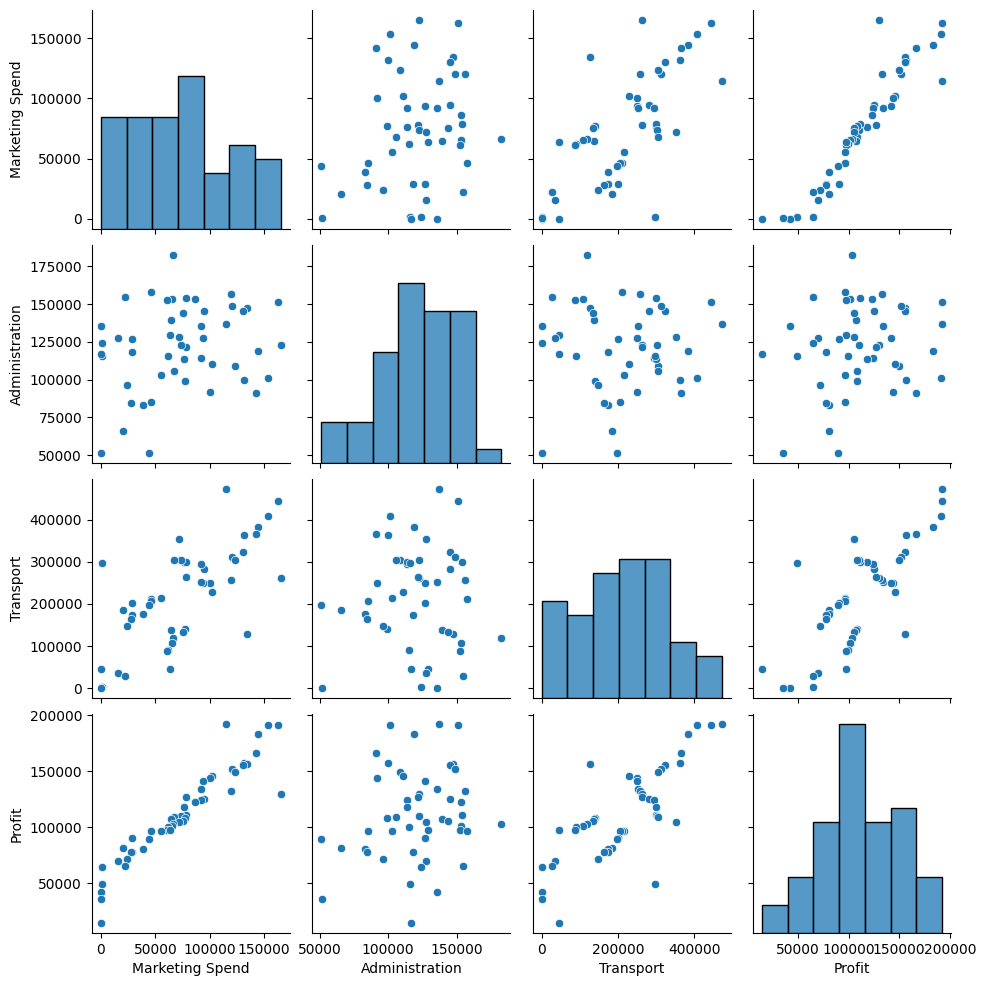

In [16]:
sns.pairplot(df)
plt.show()

## NaN value handling

In [17]:
df.isna().sum()

Marketing Spend    0
Administration     0
Transport          1
Area               0
Profit             0
dtype: int64

In [18]:
mean_transport = df.Transport.mean()
mean_transport

215331.7324489796

In [19]:
df['Transport'] = df['Transport'].fillna(mean_transport)
df

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.100000,Dhaka,192261.83
1,162597.70,151377.59,443898.530000,Ctg,191792.06
2,153441.51,101145.55,407934.540000,Rangpur,191050.39
3,144372.41,118671.85,383199.620000,Dhaka,182901.99
4,142107.34,91391.77,366168.420000,Rangpur,166187.94
5,131876.90,99814.71,362861.360000,Dhaka,156991.12
6,134615.46,147198.87,127716.820000,Ctg,156122.51
7,130298.13,145530.06,323876.680000,Rangpur,155752.60
8,120542.52,148718.95,311613.290000,Dhaka,152211.77
9,123334.88,108679.17,304981.620000,Ctg,149759.96


In [20]:
df.isna().sum()

Marketing Spend    0
Administration     0
Transport          0
Area               0
Profit             0
dtype: int64

## Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [22]:
df['Area'] = le.fit_transform(df['Area'])

In [23]:
df

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.100000,1,192261.83
1,162597.70,151377.59,443898.530000,0,191792.06
2,153441.51,101145.55,407934.540000,2,191050.39
3,144372.41,118671.85,383199.620000,1,182901.99
4,142107.34,91391.77,366168.420000,2,166187.94
5,131876.90,99814.71,362861.360000,1,156991.12
6,134615.46,147198.87,127716.820000,0,156122.51
7,130298.13,145530.06,323876.680000,2,155752.60
8,120542.52,148718.95,311613.290000,1,152211.77
9,123334.88,108679.17,304981.620000,0,149759.96


In [24]:
label_map = {
    'Area' : ['Dhaka','Ctg','Rangpur'],
    'Encoded_Area' : [1,0,2]
}
df_label = pd.DataFrame(label_map)
df_label

,Area,Encoded_Area
0,Dhaka,1
1,Ctg,0
2,Rangpur,2


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Marketing Spend  50 non-null     float64
 1   Administration   50 non-null     float64
 2   Transport        50 non-null     float64
 3   Area             50 non-null     int32  
 4   Profit           50 non-null     float64
dtypes: float64(4), int32(1)
memory usage: 1.9 KB


## Scaling

In [26]:
df.head(2)

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,1,192261.83
1,162597.70,151377.59,443898.53,0,191792.06


In [27]:
x_scaled = df.iloc[:, 0:4]
y = df.iloc[:,4]

In [28]:
x_scaled

,Marketing Spend,Administration,Transport,Area
0,114523.61,136897.80,471784.100000,1
1,162597.70,151377.59,443898.530000,0
2,153441.51,101145.55,407934.540000,2
3,144372.41,118671.85,383199.620000,1
4,142107.34,91391.77,366168.420000,2
5,131876.90,99814.71,362861.360000,1
6,134615.46,147198.87,127716.820000,0
7,130298.13,145530.06,323876.680000,2
8,120542.52,148718.95,311613.290000,1
9,123334.88,108679.17,304981.620000,0


In [29]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [30]:
from sklearn.preprocessing import MinMaxScaler
mmx = MinMaxScaler(feature_range=(0, 1))

In [31]:
for col in x_scaled.columns:
    if col == 'Area':
        continue
    else:
        x_scaled[col] = mmx.fit_transform(x_scaled[[col]])
    

In [32]:
x_scaled

,Marketing Spend,Administration,Transport,Area
0,0.692617,0.651744,1.000000,1
1,0.983359,0.761972,0.940893,0
2,0.927985,0.379579,0.864664,2
3,0.873136,0.512998,0.812235,1
4,0.859438,0.305328,0.776136,2
5,0.797566,0.369448,0.769126,1
6,0.814128,0.730161,0.270710,0
7,0.788018,0.717457,0.686493,2
8,0.729018,0.741733,0.660500,1
9,0.745906,0.436929,0.646443,0


In [33]:
from sklearn.model_selection import train_test_split as tts

In [34]:
xtrain, xtest, ytrain, ytest = tts(x_scaled,y, test_size = .2, random_state = 42)

In [35]:
from sklearn.neighbors import KNeighborsRegressor

knn_r = KNeighborsRegressor(n_neighbors=5)

In [36]:
knn_r.fit(xtrain, ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
knn_r.score(xtrain,ytrain)

0.7922893454993202

In [38]:
knn_r.score(xtest,ytest)

0.18224366367937617

In [39]:
xtest.shape

(10, 4)

In [40]:
ytest.shape

(10,)

In [41]:
ypred = knn_r.predict(xtest)
ypred

array([127239.824, 100484.194, 110598.682,  94655.746, 130487.946,
        90700.63 , 115695.392,  97124.   ,  54435.972, 113404.26 ])

# Model Evaluation

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(ytest, ypred)
mae = mean_absolute_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

print("Mean Squared Error:", mse)       # in profit^2
print("Mean Absolute Error:", mae)      # in profit units
print("R2 Score:", r2)                  # ratio, 0 to 1

Mean Squared Error: 662212599.3676155
Mean Absolute Error: 19968.8174
R2 Score: 0.18224366367937617


In [43]:
xtrain.shape

(40, 4)

In [44]:
ypred_train = knn_r.predict(xtrain)
ypred_train

array([126212.122, 156675.956, 100484.194, 136270.426, 162856.75 ,
       139121.766,  84702.136,  84702.136,  54435.972, 162856.75 ,
       139121.766, 127239.824,  96949.762,  97124.   ,  97622.448,
       157875.004,  59478.834, 143557.21 ,  96874.436, 162856.75 ,
        97622.448, 125887.092,  85025.788, 148628.298, 132359.914,
       156675.956,  94655.746,  92205.58 , 116343.516,  77625.106,
       126212.122, 126212.122, 126212.122,  54435.972, 123545.246,
       140065.924,  76272.374, 140065.924, 115706.198,  92205.58 ])

In [52]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_list_train = []
mae_list_train = []
r2_list_train = []

mse_list_test = []
mae_list_test = []
r2_list_test = []

for i in range(1, 31):

    print("K =", i)

    knn_r = KNeighborsRegressor(n_neighbors=i)
    knn_r.fit(xtrain, ytrain)

    # Train prediction
    ypred_train = knn_r.predict(xtrain)

    mse_train = mean_squared_error(ytrain, ypred_train)
    mae_train = mean_absolute_error(ytrain, ypred_train)
    r2_train = r2_score(ytrain, ypred_train)

    mse_list_train.append(mse_train)
    mae_list_train.append(mae_train)
    r2_list_train.append(r2_train)

    print("Train MSE:", mse_train)
    print("Train MAE:", mae_train)
    print("Train R2:", r2_train)

    # Test prediction
    ypred_test = knn_r.predict(xtest)

    mse_test = mean_squared_error(ytest, ypred_test)
    mae_test = mean_absolute_error(ytest, ypred_test)
    r2_test = r2_score(ytest, ypred_test)

    mse_list_test.append(mse_test)
    mae_list_test.append(mae_test)
    r2_list_test.append(r2_test)

    print("Test MSE:", mse_test)
    print("Test MAE:", mae_test)
    print("Test R2:", r2_test)
    print("------------")
print('Maximum Train MSE:', max(mse_list_train))
print('Maximum Test MSE:', max(mse_list_test))

print('Maximum Train MAE:', max(mae_list_train))
print('Maximum Test MAE:', max(mae_list_test))

print('Maximum Train R2:', max(r2_list_train))
print('Maximum Test R2:', max(r2_list_test))

K = 1
Train MSE: 0.0
Train MAE: 0.0
Train R2: 1.0
Test MSE: 501985490.3150898
Test MAE: 17466.112999999998
Test R2: 0.3801057004379086
------------
K = 2
Train MSE: 114773630.3499806
Train MAE: 8814.038625000001
Train R2: 0.9333276588879467
Test MSE: 500404767.68511236
Test MAE: 17527.208499999997
Test R2: 0.3820577109370501
------------
K = 3
Train MSE: 232775479.01262385
Train MAE: 12260.481166666666
Train R2: 0.8647800362162728
Test MSE: 502280540.39713
Test MAE: 14788.395
Test R2: 0.3797413475482917
------------
K = 4
Train MSE: 305296043.1799334
Train MAE: 13985.615749999997
Train R2: 0.822652626139083
Test MSE: 687201239.2962655
Test MAE: 20464.88525
Test R2: 0.1513855696817652
------------
K = 5
Train MSE: 357565153.4321732
Train MAE: 14506.903249999998
Train R2: 0.7922893454993202
Test MSE: 662212599.3676155
Test MAE: 19968.8174
Test R2: 0.18224366367937617
------------
K = 6
Train MSE: 443543421.5637786
Train MAE: 16048.70395833333
Train R2: 0.7423443154117104
Test MSE: 667304

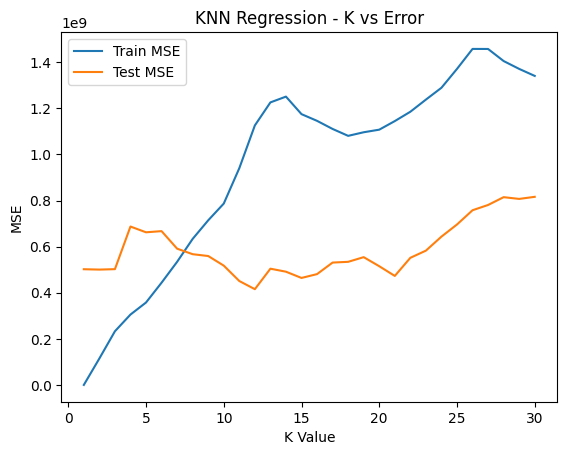

In [53]:
plt.plot(range(1,31), mse_list_train, label="Train MSE")
plt.plot(range(1,31), mse_list_test, label="Test MSE")

plt.xlabel("K Value")
plt.ylabel("MSE")
plt.title("KNN Regression - K vs Error")
plt.legend()
plt.show()

In [67]:
import numpy as np

best_k = np.argmax(r2_list_test) + 1
print("Best K:", best_k)

Best K: 12


## Without Scaling

In [54]:
df

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.100000,1,192261.83
1,162597.70,151377.59,443898.530000,0,191792.06
2,153441.51,101145.55,407934.540000,2,191050.39
3,144372.41,118671.85,383199.620000,1,182901.99
4,142107.34,91391.77,366168.420000,2,166187.94
5,131876.90,99814.71,362861.360000,1,156991.12
6,134615.46,147198.87,127716.820000,0,156122.51
7,130298.13,145530.06,323876.680000,2,155752.60
8,120542.52,148718.95,311613.290000,1,152211.77
9,123334.88,108679.17,304981.620000,0,149759.96


In [56]:
x = df.iloc[:,0:3]
y = df['Profit']

In [57]:
xtrain,xtest,ytrain,ytest = tts(x,y,test_size = .2, random_state = 40)

In [58]:
xtrain.shape

(40, 3)

In [59]:
ytrain.shape

(40,)

In [60]:
xtest.shape

(10, 3)

In [61]:
ytest.shape

(10,)

In [92]:
from sklearn.neighbors import KNeighborsRegressor
knn_r = KNeighborsRegressor(n_neighbors=5)
knn_r.fit(xtrain,ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [93]:
print('Train score: ',knn_r.score(xtrain, ytrain))
print('Test score: ',knn_r.score(xtest,ytest))

Train score:  0.8123907564490458
Test score:  0.788595246964767


In [94]:
mse = mean_squared_error(ytest, ypred)
mae = mean_absolute_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

print("Mean Squared Error:", mse)       # in profit^2
print("Mean Absolute Error:", mae)      # in profit units
print("R2 Score:", r2)                  # ratio, 0 to 1

Mean Squared Error: 267145799.27846122
Mean Absolute Error: 11007.491666666672
R2 Score: 0.9093923894444417


In [68]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_list_train = []
mae_list_train = []
r2_list_train = []

mse_list_test = []
mae_list_test = []
r2_list_test = []

for i in range(1, 31):

    print("K =", i)

    knn_r = KNeighborsRegressor(n_neighbors=i)
    knn_r.fit(xtrain, ytrain)

    # Train prediction
    ypred_train = knn_r.predict(xtrain)

    mse_train = mean_squared_error(ytrain, ypred_train)
    mae_train = mean_absolute_error(ytrain, ypred_train)
    r2_train = r2_score(ytrain, ypred_train)

    mse_list_train.append(mse_train)
    mae_list_train.append(mae_train)
    r2_list_train.append(r2_train)

    print("Train MSE:", mse_train)
    print("Train MAE:", mae_train)
    print("Train R2:", r2_train)

    # Test prediction
    ypred_test = knn_r.predict(xtest)

    mse_test = mean_squared_error(ytest, ypred_test)
    mae_test = mean_absolute_error(ytest, ypred_test)
    r2_test = r2_score(ytest, ypred_test)

    mse_list_test.append(mse_test)
    mae_list_test.append(mae_test)
    r2_list_test.append(r2_test)

    print("Test MSE:", mse_test)
    print("Test MAE:", mae_test)
    print("Test R2:", r2_test)
    print("------------")
print('Maximum Train MSE:', max(mse_list_train))
print('Maximum Test MSE:', max(mse_list_test))

print('Maximum Train MAE:', max(mae_list_train))
print('Maximum Test MAE:', max(mae_list_test))

print('Maximum Train R2:', max(r2_list_train))
print('Maximum Test R2:', max(r2_list_test))

K = 1
Train MSE: 0.0
Train MAE: 0.0
Train R2: 1.0
Test MSE: 373455598.44481
Test MAE: 10695.813000000004
Test R2: 0.8733353864628464
------------
K = 2
Train MSE: 67238357.23390563
Train MAE: 5375.346875
Train R2: 0.9459082282720688
Test MSE: 345927314.36721754
Test MAE: 10721.7405
Test R2: 0.8826721308537449
------------
K = 3
Train MSE: 110481231.59742579
Train MAE: 6621.435416666665
Train R2: 0.9111202919637195
Test MSE: 267145799.27846122
Test MAE: 11007.491666666672
Test R2: 0.9093923894444417
------------
K = 4
Train MSE: 149507541.30437914
Train MAE: 7259.086000000001
Train R2: 0.8797244886916613
Test MSE: 474380089.29586065
Test MAE: 15269.141750000004
Test R2: 0.839104913862309
------------
K = 5
Train MSE: 233206214.83263636
Train MAE: 10336.384950000001
Train R2: 0.8123907564490458
Test MSE: 623301854.8285563
Test MAE: 16364.134400000004
Test R2: 0.788595246964767
------------
K = 6
Train MSE: 289576026.1744915
Train MAE: 12251.857166666665
Train R2: 0.7670424895834088
Test 

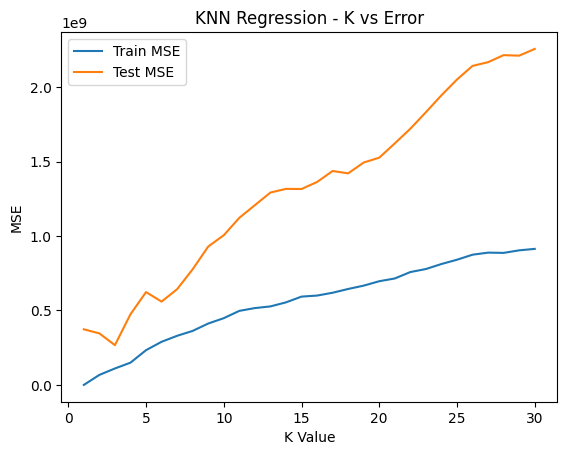

In [81]:
plt.plot(range(1,31), mse_list_train, label="Train MSE")
plt.plot(range(1,31), mse_list_test, label="Test MSE")

plt.xlabel("K Value")
plt.ylabel("MSE")
plt.title("KNN Regression - K vs Error")
plt.legend()
plt.show()

In [69]:
best_k = np.argmax(r2_list_test) + 1
print("Best K:", best_k)

Best K: 3


#  Final model building based on optimal value of k = 3

In [82]:
final_model = KNeighborsRegressor(n_neighbors=3)
final_model.fit(xtrain, ytrain)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [83]:
ypred = final_model.predict(xtest)
ypred

array([ 89397.82      , 102166.49333333,  59173.01333333,  82917.91      ,
        59173.01333333, 177228.39      , 112520.09      , 163217.69      ,
       138233.46666667, 177228.39      ])

In [96]:
print('Train score: ',final_model.score(xtrain, ytrain))
print('Test score: ',final_model.score(xtest,ytest))

Train score:  0.9111202919637195
Test score:  0.9093923894444417


In [97]:
mse = mean_squared_error(ytest, ypred)
mae = mean_absolute_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

print("Final MSE:", mse)
print("Final MAE:", mae)
print("Final R2 Score:", r2)

Final MSE: 267145799.27846122
Final MAE: 11007.491666666672
Final R2 Score: 0.9093923894444417


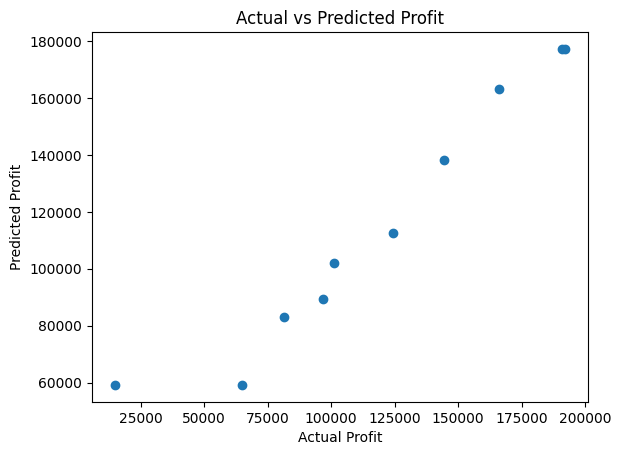

In [98]:
import matplotlib.pyplot as plt

plt.scatter(ytest, ypred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.show()

In [99]:
new_data = [[120000, 130000, 300000]]  # Marketing, Admin, Transport
prediction = final_model.predict(new_data)

print("Predicted Profit:", prediction)

Predicted Profit: [152574.77666667]


C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


# Save Model

In [100]:
import pickle
pickle.dump(final_model,open('knn_regressor_model.pkl','wb'))

"""
import pickle

with open('knn_regressor_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
"""

"\nimport pickle\n\nwith open('knn_regressor_model.pkl', 'wb') as f:\n    pickle.dump(final_model, f)\n"

In [101]:
# Load model -> Use this code to load the model for prediction
""" 
import pickle

with open('knn_regressor_model.pkl', 'rb') as f:
    model = pickle.load(f)
"""

" \nimport pickle\n\nwith open('knn_regressor_model.pkl', 'rb') as f:\n    model = pickle.load(f)\n"

# Observations:
### 1. When we applied normalizaion such as MinMaxScaling we got lower train and test score along with higher MSE, MAE and R2 score. We got the best k value which is 12 after running a loop.
### 2. But when we fitted the model without scaling or normalization we got higher train and test score along with lower MSE, MAE and R2 score. We got the best k value which is 3 after running a loop. Finally we built a final model base on K value 3 and acquired highest train and test score compared to previous scores. Also, we got the lowest MSE, MAE and R2 score 